#Menghubungkan dengan google collab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/MyDrive/praktikum_ml/praktikum11"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

#Membaca dataset

In [ ]:
df = pd.read_csv(path + "/data/Iris.csv")
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


#Data Prepation

##Menampilkan informasi detail

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


##Cek Missing Value dan Data Duplikat

In [ ]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [ ]:
df.duplicated().sum()

np.int64(0)

##Menampilkan statistika deskriptif dari dataset

In [ ]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


##Menghitung jumlah pada kolom Species

In [ ]:
df["Species"].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


##Cek nilai pada kolom Species

In [ ]:
df["Species"].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

##Cek Variasi Spesiesnya

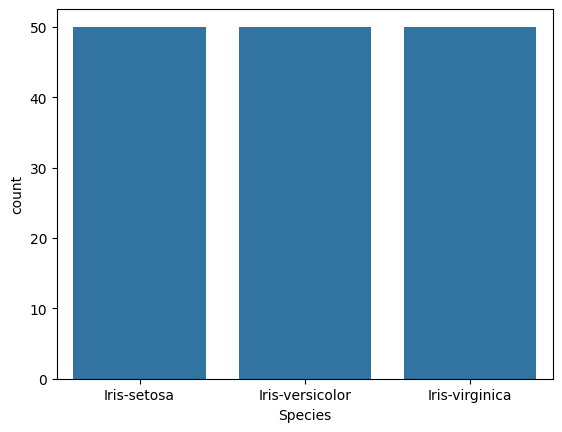

In [ ]:
sns.countplot(x="Species", data=df)
plt.show()

#Pemilihan Fitur

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["SpeciesEncoded"] = le.fit_transform(df["Species"])

In [ ]:
#Fitur untuk clustering
X = df.drop(["Id", "Species", "SpeciesEncoded"], axis=1)
X

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
X[7:15]

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1
10,5.4,3.7,1.5,0.2
11,4.8,3.4,1.6,0.2
12,4.8,3.0,1.4,0.1
13,4.3,3.0,1.1,0.1
14,5.8,4.0,1.2,0.2


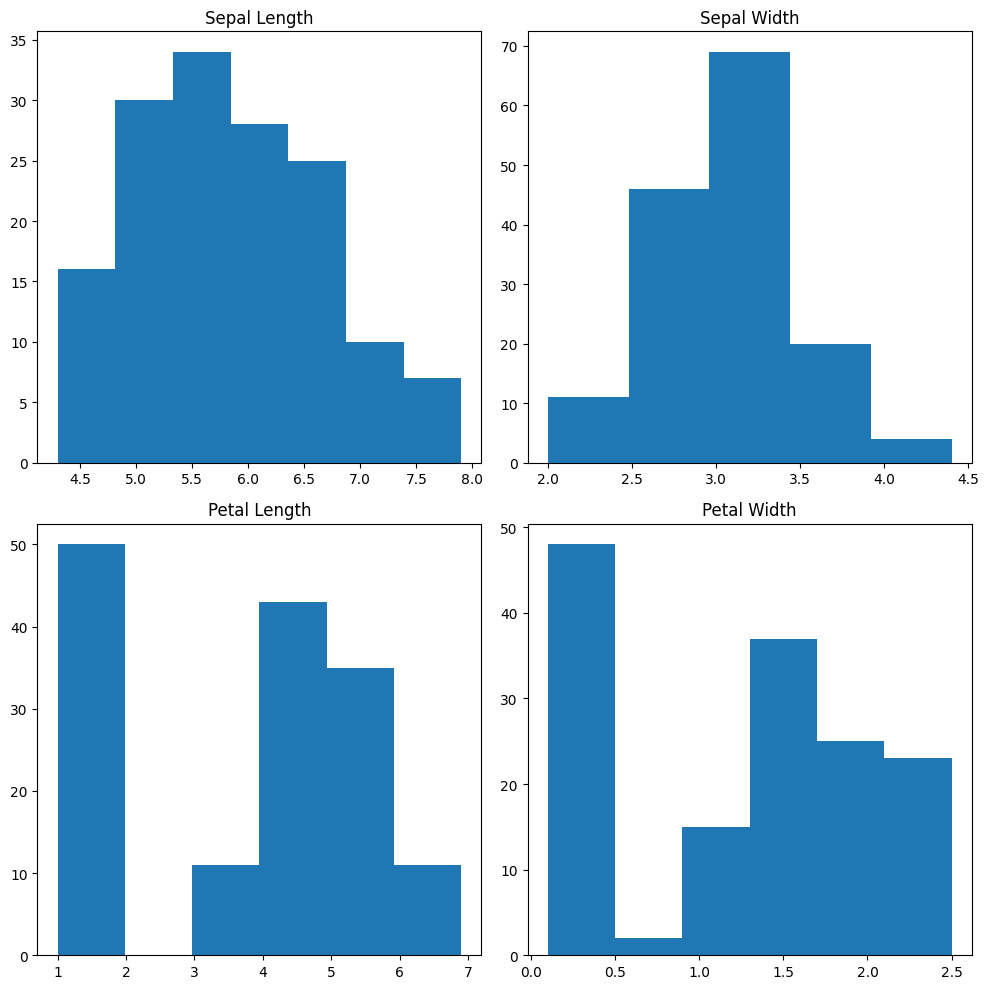

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Histogram 1: Sepal length
axes[0,0].set_title("Sepal Length")
axes[0,0].hist(X["SepalLengthCm"], bins=7)

# Histogram 2: Sepal width
axes[0,1].set_title("Sepal Width")
axes[0,1].hist(X["SepalWidthCm"], bins=5)

# Histogram 3: Petal length
axes[1,0].set_title("Petal Length")
axes[1,0].hist(X["PetalLengthCm"], bins=6)

# Histogram 4: Petal width
axes[1,1].set_title("Petal Width")
axes[1,1].hist(X["PetalWidthCm"], bins=6)

plt.tight_layout()
plt.show()

#Normalisasi Data

##StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]

X = scaler.fit_transform(X)
X[:5]

array([[-0.90068117,  1.03205722, -1.3412724 , -1.31297673],
       [-1.14301691, -0.1249576 , -1.3412724 , -1.31297673],
       [-1.38535265,  0.33784833, -1.39813811, -1.31297673],
       [-1.50652052,  0.10644536, -1.2844067 , -1.31297673],
       [-1.02184904,  1.26346019, -1.3412724 , -1.31297673]])

#Menentukan Jumlah Cluster (K) dengan Elbow Method

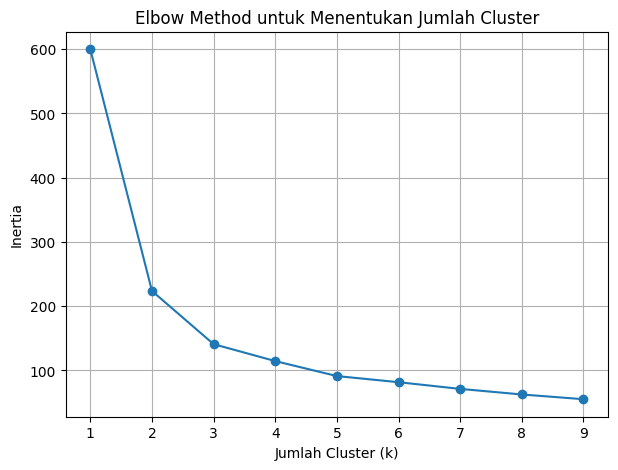

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Inisialisasi list untuk menyimpan nilai Inertia
inertia_list = []
K_range = range(1, 10) # Cek K dari 1 sampai 9

# Lakukan K-Means untuk setiap nilai K dalam range
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10) # Tambahkan n_init=10 untuk menghindari warning
    km.fit(X)
    inertia_list.append(km.inertia_)

# Visualisasi Elbow Method
plt.figure(figsize=(7,5))
plt.plot(K_range, inertia_list, marker='o')
plt.title("Elbow Method untuk Menentukan Jumlah Cluster")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

#Membangun Model K-Means

In [ ]:
# Inisialisasi model K-Means dengan K=3
kmeans = KMeans(
    n_clusters=3, #karena dataset Iris ada 3 Species
    init='k-means++',
    random_state=42,
)

##latih model

In [ ]:
#kmeans.fit(X)

##Prediksi cluster untuk data x

In [ ]:
#labels = kmeans.predict(X)

##Masukan ke dataframe

In [ ]:
#df["Cluster"] = labels

##Langkah lebih cepat

In [ ]:
df["Cluster"] = kmeans.fit_predict(X)
print("Cluster ditemukan:", df["Cluster"].unique())

Cluster ditemukan: [1 2 0]


#Evaluasi Kualitas Clustering

In [ ]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X, df["Cluster"])
print("\n===== SILHOUETTE SCORE =====")
print("Silhouette Score:", sil_score)
# Nilai mendekati +1 menunjukkan clustering yang baik


===== SILHOUETTE SCORE =====
Silhouette Score: 0.4787241921049546


In [ ]:
print("\n===== CONFUSION MATRIX=====")
cm = confusion_matrix(df["SpeciesEncoded"], df["Cluster"])
print(cm)


===== CONFUSION MATRIX=====
[[ 0 32 18]
 [46  0  4]
 [50  0  0]]


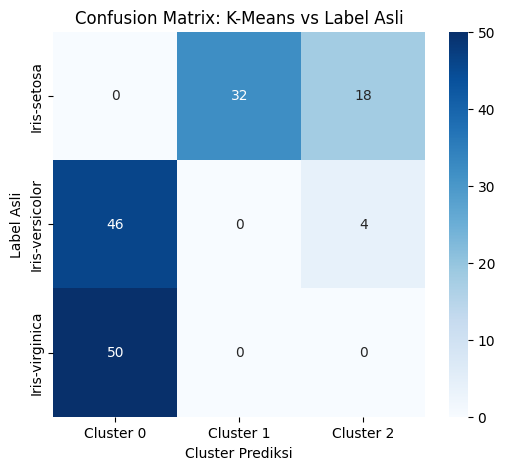

In [ ]:
# Visualisasi Confusion Matrix dengan Seaborn Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Cluster 0", "Cluster 1", "Cluster 2"],
    yticklabels=le.classes_
)
plt.title("Confusion Matrix: K-Means vs Label Asli")
plt.xlabel("Cluster Prediksi")
plt.ylabel("Label Asli")
plt.show()

#Visualisasi 2D

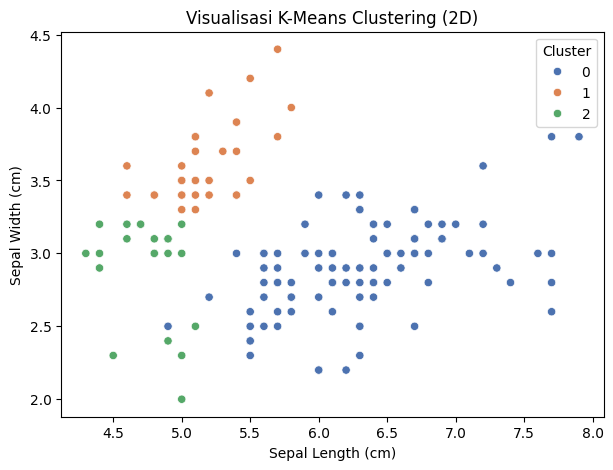

In [ ]:
# Visualisasi K-Means Clustering 2D
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=df["SepalLengthCm"], # Sumbu X
    y=df["SepalWidthCm"], # Sumbu Y
    hue=df["Cluster"], # Warna berdasarkan cluster
    palette="deep"
)
plt.title("Visualisasi K-Means Clustering (2D)")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.show()
# Plot ini menunjukkan satu cluster (warna hijau) terpisah jelas dari dua cluster lainnya. [cite: 363, 364]

In [ ]:
#Visualisasi the cluster
plt.scatter

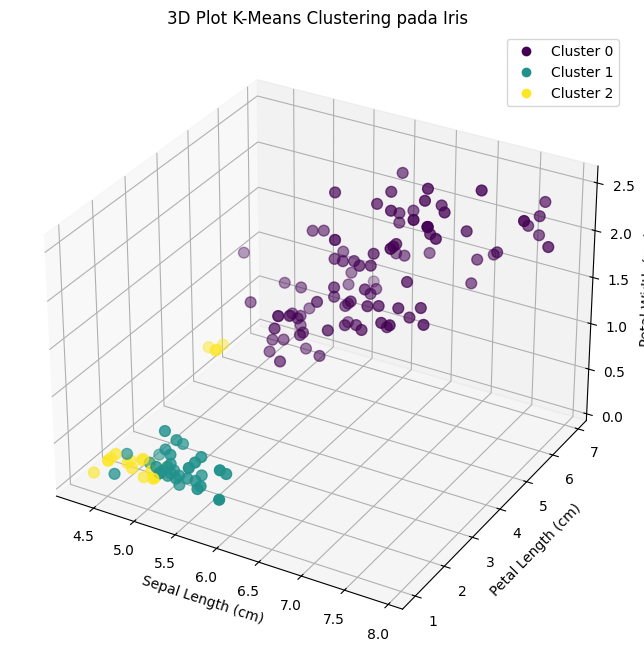

In [ ]:
# Visualisasi K-Means Clustering 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d') # Membuat subplot 3D

# Scatter plot 3D
scatter = ax.scatter(
    df["SepalLengthCm"],
    df["PetalLengthCm"],
    df["PetalWidthCm"],
    c=df["Cluster"],
    s=60
)

# Pengaturan Judul dan Label Sumbu
ax.set_title("3D Plot K-Means Clustering pada Iris")
ax.set_xlabel("Sepal Length (cm)")
ax.set_ylabel("Petal Length (cm)")
ax.set_zlabel("Petal Width (cm)")

# Membuat Legenda
legend_labels = [f"Cluster {i}" for i in range(3)]
ax.legend(handles=scatter.legend_elements()[0], labels=legend_labels)

plt.show()
# Plot ini menunjukkan separasi yang lebih komprehensif dari ketiga cluster. [cite: 412, 413]